In [ ]:


#load library
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Conv2D,MaxPooling2D,Flatten,Dense
from tensorflow.keras.datasets import fashion_mnist

#loading dataset

(x_train,y_train),(x_test,y_test) = fashion_mnist.load_data()

#normalize data
x_train = x_train/255
x_test = x_test/255

#reshape
x_train = x_train.reshape(60000,28,28,1)
x_test = x_test.reshape(10000,28,28,1)

#class name
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

#model cnn building

model = Sequential([

                    #input layer
                    Input(shape=(28,28,1)),

                    #convolutional layer
                    Conv2D(32,(3,3),activation = 'relu'),

                    #maxpooling
                    MaxPooling2D((2,2)),

                    #flatten
                    Flatten(),

                    #fully connected
                    Dense(64,activation = 'relu'),

                    #output
                    Dense(10,activation = 'softmax')

])

# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#train the model
model.fit(

          x_train,
          y_train,
          epochs = 2,
          validation_split =0.2,
          batch_size = 32
)

loss , accuracy = model.evaluate(x_test,y_test)
print("the accuracy is:",accuracy)

#prediction

predictions = model.predict(x_test)

#printing sample prediction

for i in range(10):

  predicted_lable = np.argmax(predictions[i])
  print("Image", i+1)
  print("actual lable:",class_names[y_test[i]])
  print("Predicted lable:",class_names[predicted_lable])
  print()











Epoch 1/2
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 26ms/step - accuracy: 0.8492 - loss: 0.4346 - val_accuracy: 0.8822 - val_loss: 0.3278
Epoch 2/2
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - accuracy: 0.8945 - loss: 0.2950 - val_accuracy: 0.8950 - val_loss: 0.2995
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8848 - loss: 0.3119
the accuracy is: 0.8848000168800354
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Image 1
actual lable: Ankle boot
Predicted lable: Ankle boot

Image 2
actual lable: Pullover
Predicted lable: Pullover

Image 3
actual lable: Trouser
Predicted lable: Trouser

Image 4
actual lable: Trouser
Predicted lable: Trouser

Image 5
actual lable: Shirt
Predicted lable: Shirt

Image 6
actual lable: Trouser
Predicted lable: Trouser

Image 7
actual lable: Coat
Predicted lable: Coat

Image 8
actual lable: Shirt
Predicted lable: Shirt

Image 9
actual lable: Sandal
Predicted lable: Sandal

Image 10
actual lable: Sneaker
Predicted lable: Sneaker



Epoch 1/2
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.8421 - loss: 0.4515 - val_accuracy: 0.8817 - val_loss: 0.3376
Epoch 2/2
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.8933 - loss: 0.3037 - val_accuracy: 0.8952 - val_loss: 0.2953
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8866 - loss: 0.3101
Accuracy is: 0.8866000175476074
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


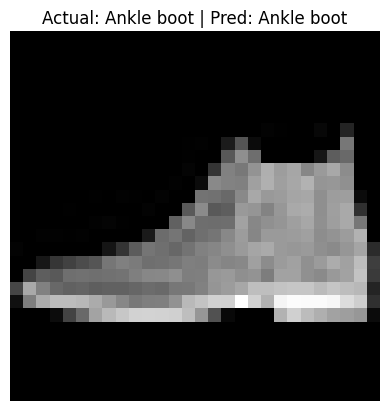

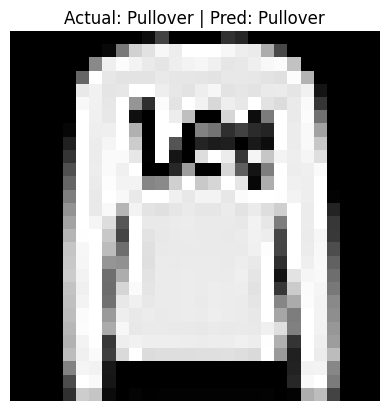

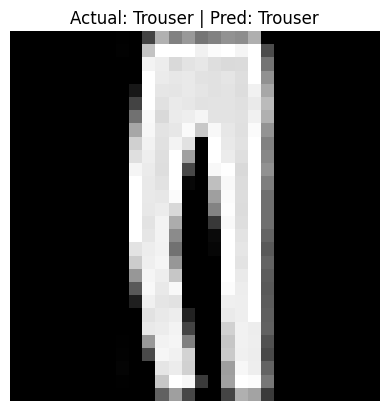

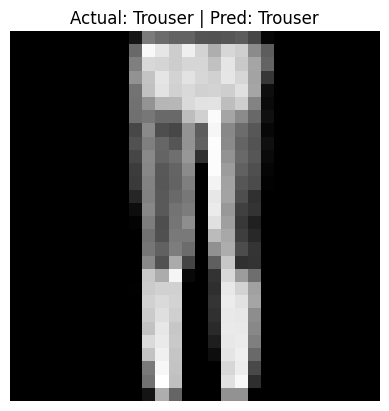

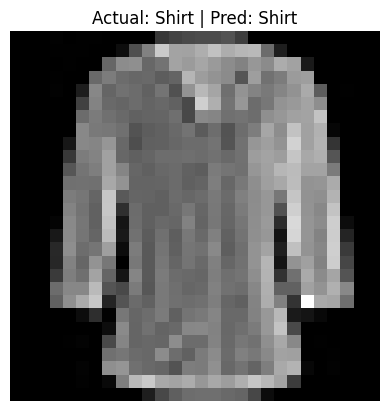

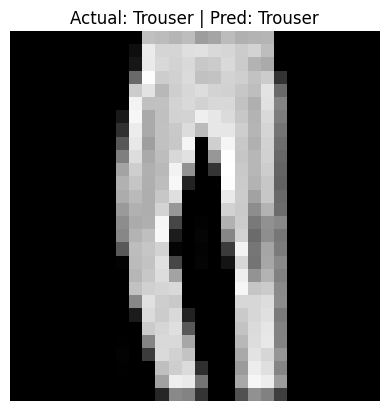

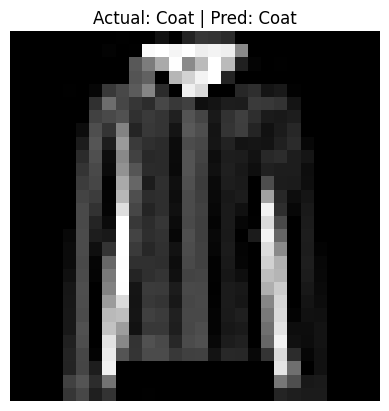

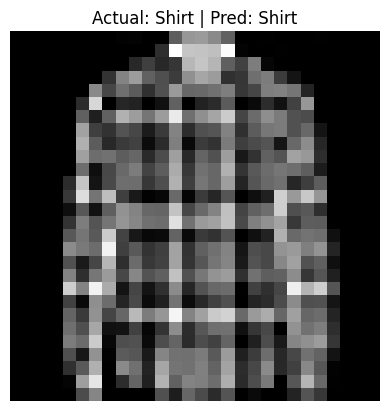

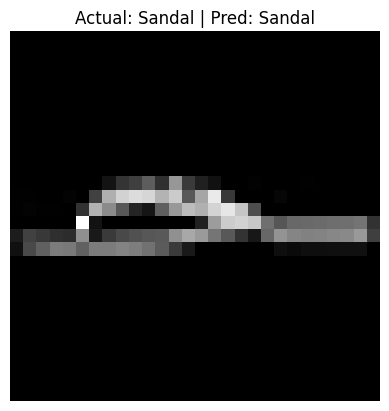

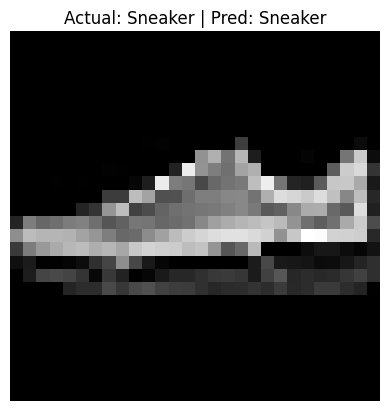

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.datasets import fashion_mnist

# load data
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# reshape
x_train = x_train.reshape(60000, 28, 28, 1)
x_test = x_test.reshape(10000, 28, 28, 1)

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
 ]

# CNN model
model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# train
model.fit(x_train, y_train, epochs=2, batch_size=32, validation_split=0.2)

# evaluate
loss, accuracy = model.evaluate(x_test, y_test)
print("Accuracy is:", accuracy)

# predictions
predictions = model.predict(x_test)

# display images with predictions
for i in range(10):
    predicted_label = np.argmax(predictions[i])

    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Actual: " + class_names[y_test[i]] +
              " | Pred: " + class_names[predicted_label])
    plt.axis('off')
    plt.show()